In [1]:
import pandas as pd

url = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

needed_cols = [
    'Date received',
    'Date sent to company',
    'Product',
    'Submitted via',
    'Company response to consumer',
    'Timely response?'
]

start_date = pd.to_datetime('2017-01-20')

print("Processing in chunks to save RAM...")

chunks = []
for chunk in pd.read_csv(url,
                         compression='zip',
                         usecols=needed_cols,
                         chunksize=100000,
                         low_memory=False):

    chunk['Date received'] = pd.to_datetime(chunk['Date received'])
    filtered_chunk = chunk[chunk['Date received'] >= start_date]

    chunks.append(filtered_chunk)

df = pd.concat(chunks, ignore_index=True)

print(f"Success! Dataframe loaded with {len(df):,} rows.")
print(f"Date range: {df['Date received'].min().date()} to {df['Date received'].max().date()}")

df.head()

Processing in chunks to save RAM...
Success! Dataframe loaded with 13,443,074 rows.
Date range: 2017-01-20 to 2026-03-25


,Date received,Product,Submitted via,Date sent to company,Company response to consumer,Timely response?
0,2020-07-06,"Credit reporting, credit repair services, or o...",Web,2020-07-06,Closed with explanation,Yes
1,2019-12-26,Credit card or prepaid card,Web,2019-12-26,Closed with explanation,Yes
2,2020-05-08,"Credit reporting, credit repair services, or o...",Web,2020-05-08,Closed with explanation,Yes
3,2024-01-05,Credit reporting or other personal consumer re...,Web,2024-01-05,Closed with non-monetary relief,Yes
4,2024-01-21,Credit reporting or other personal consumer re...,Web,2024-01-21,Closed with explanation,Yes


In [2]:
df.shape

(13443074, 6)

In [3]:
new_names = {'Date received': 'date_received', 'Product': 'product', 'Submitted via':'submitted_via', 'Date sent to company':'date_sent_to_company', 'Company response to consumer':'company_response_to_consumer', 'Timely response?':'timely_response'}
df = df.rename(columns=new_names)

In [4]:
fraction_similar = (((df['date_received'] == df['date_sent_to_company']).sum())/df.shape[0])
print(f"Similarity between the date the CFPB received the complaint and the date the CFPB sent the complaint to the company: {fraction_similar:.2%}")

Similarity between the date the CFPB received the complaint and the date the CFPB sent the complaint to the company: 95.15%


In [5]:
# https://cfpb.github.io/api/ccdb/fields.html
df.drop('date_received', axis = 1, inplace = True)
df['date_sent_to_company'] = pd.to_datetime(df['date_sent_to_company'])
df.head()

,product,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response
0,"Credit reporting, credit repair services, or o...",Web,2020-07-06,Closed with explanation,Yes
1,Credit card or prepaid card,Web,2019-12-26,Closed with explanation,Yes
2,"Credit reporting, credit repair services, or o...",Web,2020-05-08,Closed with explanation,Yes
3,Credit reporting or other personal consumer re...,Web,2024-01-05,Closed with non-monetary relief,Yes
4,Credit reporting or other personal consumer re...,Web,2024-01-21,Closed with explanation,Yes


In [6]:
df = df[df['company_response_to_consumer'] != 'In progress']
bins = [
    pd.Timestamp('2017-01-20'),
    pd.Timestamp('2021-01-20'),
    pd.Timestamp('2025-01-20'),
    pd.Timestamp('2029-01-20')
]

labels = ['Trump_One', 'Biden', 'Trump_Two']

df['president_date_sent_to_company'] = pd.cut(df['date_sent_to_company'], bins=bins, labels=labels, right=False, ordered=False)
df.head()

,product,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,president_date_sent_to_company
0,"Credit reporting, credit repair services, or o...",Web,2020-07-06,Closed with explanation,Yes,Trump_One
1,Credit card or prepaid card,Web,2019-12-26,Closed with explanation,Yes,Trump_One
2,"Credit reporting, credit repair services, or o...",Web,2020-05-08,Closed with explanation,Yes,Trump_One
3,Credit reporting or other personal consumer re...,Web,2024-01-05,Closed with non-monetary relief,Yes,Biden
4,Credit reporting or other personal consumer re...,Web,2024-01-21,Closed with explanation,Yes,Biden


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12966094 entries, 0 to 13443073
Data columns (total 6 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   product                         object        
 1   submitted_via                   object        
 2   date_sent_to_company            datetime64[ns]
 3   company_response_to_consumer    object        
 4   timely_response                 object        
 5   president_date_sent_to_company  category      
dtypes: category(1), datetime64[ns](1), object(4)
memory usage: 605.9+ MB


In [8]:
df.drop('date_sent_to_company', axis = 1, inplace = True)

In [9]:
df.describe(include='all')

,product,submitted_via,company_response_to_consumer,timely_response,president_date_sent_to_company
count,12966094,12966094,12966073,12966094,12966094
unique,21,7,5,2,3
top,Credit reporting or other personal consumer re...,Web,Closed with explanation,Yes,Trump_Two
freq,8448321,12581838,7887888,12892516,6162139


In [10]:
missing_values = df.isnull().sum()

missing_values_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})
missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
company_response_to_consumer,21,0.000162
product,0,0.000000
submitted_via,0,0.000000
timely_response,0,0.000000
president_date_sent_to_company,0,0.000000


In [11]:
df.dropna(inplace=True)
df.head()

,product,submitted_via,company_response_to_consumer,timely_response,president_date_sent_to_company
0,"Credit reporting, credit repair services, or o...",Web,Closed with explanation,Yes,Trump_One
1,Credit card or prepaid card,Web,Closed with explanation,Yes,Trump_One
2,"Credit reporting, credit repair services, or o...",Web,Closed with explanation,Yes,Trump_One
3,Credit reporting or other personal consumer re...,Web,Closed with non-monetary relief,Yes,Biden
4,Credit reporting or other personal consumer re...,Web,Closed with explanation,Yes,Biden


In [12]:
from sklearn.model_selection import train_test_split
ohe_cols = ['product', 'submitted_via', 'company_response_to_consumer',
       'timely_response']
ohe_df = pd.get_dummies(df, columns=ohe_cols, dtype=int, drop_first=True)

In [13]:
ohe_df.columns

Index(['president_date_sent_to_company', 'product_Checking or savings account',
       'product_Consumer Loan', 'product_Credit card',
       'product_Credit card or prepaid card', 'product_Credit reporting',
       'product_Credit reporting or other personal consumer reports',
       'product_Credit reporting, credit repair services, or other personal consumer reports',
       'product_Debt collection', 'product_Debt or credit management',
       'product_Money transfer, virtual currency, or money service',
       'product_Money transfers', 'product_Mortgage',
       'product_Other financial service', 'product_Payday loan',
       'product_Payday loan, title loan, or personal loan',
       'product_Payday loan, title loan, personal loan, or advance loan',
       'product_Prepaid card', 'product_Student loan',
       'product_Vehicle loan or lease', 'product_Virtual currency',
       'submitted_via_Fax', 'submitted_via_Phone', 'submitted_via_Postal mail',
       'submitted_via_Referral

In [ ]:
# https://stackoverflow.com/questions/29294983/how-to-calculate-correlation-between-all-columns-and-remove-highly-correlated-on
X = ohe_df.drop(['president_date_sent_to_company'], axis = 1)
y = ohe_df['president_date_sent_to_company']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5)
corr_matrix = X_train.corr('pearson').abs()
corr_pairs = corr_matrix.unstack()
highly_correlated_pairs = corr_pairs[
    (corr_pairs > 0.8) &
    (corr_pairs < 1.0)
].sort_values(ascending=False)
print("Columns with correlation above 0.8:")
print(highly_correlated_pairs)

In [ ]:
# source: https://www.statology.org/cramers-v-in-python/
from scipy.stats import chi2_contingency
import numpy as np
for col1 in X_train.columns:
    for col2 in X_train.columns:
        if col1 == col2:
            continue
        table = pd.crosstab(
            X_train[col1],
            X_train[col2]
        )

        if table.shape[0] < 2 or table.shape[1] < 2:
            continue

        chi2, p_value, dof, expected = chi2_contingency(table)

        n = table.values.sum()
        min_dim = min(table.shape) - 1

        V = np.sqrt((chi2 / n) / min_dim)

        if V >= 0.7:
            print(f"{col1} vs {col2}")
            print(f"  Cramér's V: {V:.3f}")
            print(f"  p-value: {p_value:.3e}\n")

company_response_to_consumer_Closed with explanation vs company_response_to_consumer_Closed with non-monetary relief
  Cramér's V: 0.775
  p-value: 0.000e+00

company_response_to_consumer_Closed with non-monetary relief vs company_response_to_consumer_Closed with explanation
  Cramér's V: 0.775
  p-value: 0.000e+00



In [ ]:
highly_correlated_cols = ['company_response_to_consumer_Closed with explanation']
X_train.drop(highly_correlated_cols, axis = 1, inplace = True)
X_test.drop(highly_correlated_cols, axis = 1, inplace = True)

In [ ]:
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = X_train.copy()

vif_data['intercept'] = 1

vif_series = pd.DataFrame()
vif_series["Feature"] = vif_data.columns
vif_series["VIF"] = [variance_inflation_factor(vif_data.values, i)
                     for i in range(vif_data.shape[1])]

print(vif_series[vif_series['Feature'] != 'intercept'].sort_values(by="VIF", ascending=False))

                                              Feature          VIF
21                                  submitted_via_Web  1021.067360
20                             submitted_via_Referral   525.628374
18                                submitted_via_Phone   348.052535
19                          submitted_via_Postal mail   202.174482
17                                  submitted_via_Fax    61.140716
5   product_Credit reporting, credit repair servic...    11.671819
6                             product_Debt collection     6.022966
9                                    product_Mortgage     4.899847
3                 product_Credit card or prepaid card     3.013449
0                 product_Checking or savings account     2.733676
4                            product_Credit reporting     2.673743
22                         submitted_via_Web Referral     2.638766
2                                 product_Credit card     2.009794
14                               product_Student loan     1.88

In [ ]:
highly_correlated_cols = ['submitted_via_Fax', 'product_Other financial service']
X_train.drop(highly_correlated_cols, axis = 1, inplace = True)
X_test.drop(highly_correlated_cols, axis = 1, inplace = True)

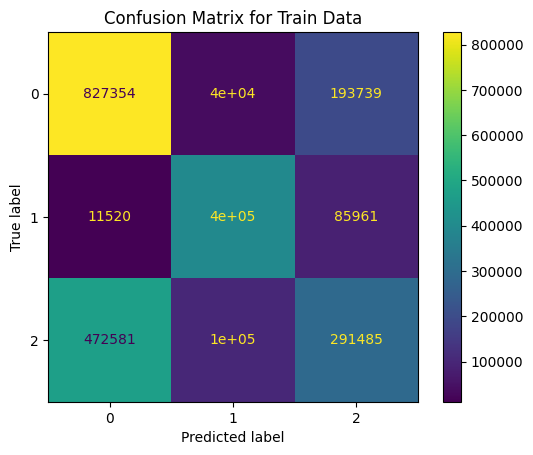

Accuracy on Training: 0.6262921629534728


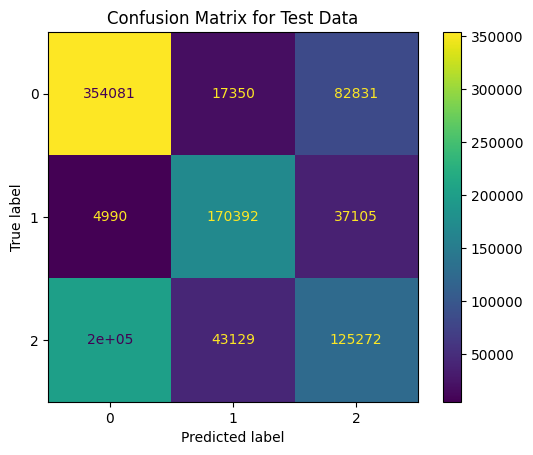

Test Set Accuracy: 0.6261570382134607


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt

lr = LogisticRegression(max_iter=10000, random_state=5).fit(X_train, y_train)
predictions_training = lr.predict(X_train)
cm = confusion_matrix(y_train, predictions_training)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Train Data')
plt.show()
print('Accuracy on Training:', accuracy_score(y_train, predictions_training))
print('Balanced Accuracy on Training:', balanced_accuracy_score(y_train, predictions_training))
predictions = lr.predict(X_test)
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Test Data')
plt.show()
print('Test Set Accuracy:', accuracy_score(y_test, predictions))
print('Test Set Balanced Accuracy:', balanced_accuracy_score(y_test, predictions))